In [17]:
import sys

import pandas as pd

import matplotlib

In [18]:

df = pd.read_csv("Teen_Mental_Health_Dataset.csv")
display(df.head())
df.info()
display(df.describe())
df.shape

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 122.0 KB


,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


(1200, 13)

In [19]:
df.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

In [20]:
df.duplicated().sum()

np.int64(0)

depression_label
0    1169
1      31
Name: count, dtype: int64

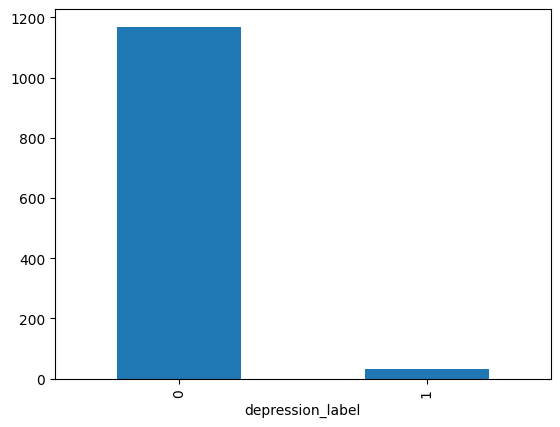

In [21]:

counts = df['depression_label'].value_counts()
counts.plot.bar()
counts

The dataset is severely imbalanced, with the positive class (depression_label=1) representing only 2.6% of samples. This limits the usefulness of accuracy as an evaluation metric, motivating our choice of F1 and ROC-AUC, and requires the use of stratified sampling and class-weighted models.

In [22]:
X = df.drop(columns=['depression_label'])   # 拿掉答案那欄,剩下都是線索
y = df['depression_label']                  # 只挑「答案」那欄
X.shape, y.shape                             # 確認形狀

((1200, 12), (1200,))

In [23]:
X = pd.get_dummies(X, drop_first=True, dtype=int)
X.head(10)

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,gender_male,platform_usage_Instagram,platform_usage_TikTok,social_interaction_level_low,social_interaction_level_medium
0,14,7.9,7.4,2.9,3.01,1.5,2,2,1,1,1,0,1,0
1,19,1.9,8.0,2.9,3.22,0.8,8,1,10,0,0,1,0,0
2,17,1.3,7.6,0.5,3.92,0.0,2,4,2,0,1,0,0,0
3,15,7.4,6.9,1.6,3.48,0.8,1,7,9,1,0,1,0,1
4,15,4.7,4.9,3.0,2.37,1.4,3,5,2,0,0,0,0,1
5,19,7.4,4.4,2.4,2.63,0.6,3,5,7,0,0,0,0,0
6,18,2.5,6.4,2.4,2.63,0.7,2,2,5,0,1,0,1,0
7,16,4.0,4.2,0.5,2.40,1.3,6,10,5,1,0,0,1,0
8,19,3.3,5.0,2.1,2.04,0.9,1,10,9,0,0,1,0,0
9,15,1.9,4.9,1.5,3.77,1.1,1,1,4,1,0,1,0,0


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train.shape, X_test.shape

((960, 14), (240, 14))

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

X_train.shape, X_test.shape

((960, 14), (240, 14))

In [26]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import f1_score, roc_auc_score, classification_report

In [32]:
model = SGDClassifier(
    random_state=42, #確保每次運行結果一致
    class_weight='balanced', #自動調整類別權重以處理不平衡數據
    tol=1e-3, #設定收斂容忍度 
            #   float or None, default=1e-3
            #   The stopping criterion. If it is not None, 
            #   training will stop when (loss > best_loss - tol) for n_iter_no_change consecutive epochs. 
            #   Convergence is checked against the training loss or the validation loss depending on 
            #   the early_stopping parameter. Values must be in the range [0.0, inf).
    early_stopping=True, #啟用早停機制
            # bool, default=False
            # Whether to use early stopping to terminate training when validation score is not improving. 
            # If set to True, it will automatically set aside 10% of training data as validation and terminate training when validation score is not improving by at least tol for n_iter_no_change consecutive epochs. 
            # Only effective when solver='sgd' or 'adam'.
    n_iter_no_change=5, #設定早停的耐心值
            # int, default=5
            # Number of iterations with no improvement to wait before early stopping.
    verbose=0 # 0: no output, 1: output progress and performance, 2: output progress only
)

param_grid = {
    'loss': ['log_loss', 'hinge', 'modified_huber'], #選擇不同的損失函數來適應不同的問題特性
    'penalty': ['l2', 'l1', 'elasticnet'], #選擇不同的正則化方法來控制模型複雜度和防止過擬合
    'alpha': [1e-4, 1e-3, 1e-2], #調整正則化強度以找到最佳的偏差-方差平衡
    'learning_rate': ['optimal', 'invscaling', 'adaptive'], #選擇不同的學習率調整策略來提高收斂速度和模型性能
    'eta0': [0.001, 0.01], #設定初始學習率以影響模型的收斂行為和最終性能
    'max_iter': [1000, 2000] #增加最大迭代次數以確保模型有足夠的機會收斂到最佳解
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) #使用分層K折交叉驗證來確保每個折中類別分佈的一致性，從而獲得更可靠的模型評估結果

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='f1', #使用F1分數作為評估指標，因為它在處理不平衡數據時能夠更好地平衡精確率和召回率
    cv=cv,
    n_jobs=-1, #使用所有可用的CPU核心來加速網格搜索過程
    verbose=2 #設置詳細程度為2以獲得每個參數組合的進度更新，從而更好地監控網格搜索過程
)

grid.fit(X_train, y_train) #在訓練數據上執行網格搜索以找到最佳的超參數組合，從而提高模型的性能和泛化能力


Fitting 5 folds for each of 324 candidates, totalling 1620 fits
[CV] END alpha=0.0001, eta0=0.001, learning_rate=optimal, loss=log_loss, max_iter=1000, penalty=l2; total time=   0.0s
[CV] END alpha=0.0001, eta0=0.001, learning_rate=optimal, loss=log_loss, max_iter=1000, penalty=l2; total time=   0.0s
[CV] END alpha=0.0001, eta0=0.001, learning_rate=optimal, loss=log_loss, max_iter=1000, penalty=l2; total time=   0.0s
[CV] END alpha=0.0001, eta0=0.001, learning_rate=optimal, loss=log_loss, max_iter=1000, penalty=l1; total time=   0.0s
[CV] END alpha=0.0001, eta0=0.001, learning_rate=optimal, loss=log_loss, max_iter=1000, penalty=l2; total time=   0.0s
[CV] END alpha=0.0001, eta0=0.001, learning_rate=optimal, loss=log_loss, max_iter=1000, penalty=l2; total time=   0.0s
[CV] END alpha=0.0001, eta0=0.001, learning_rate=optimal, loss=log_loss, max_iter=1000, penalty=l1; total time=   0.0s
[CV] END alpha=0.0001, eta0=0.001, learning_rate=optimal, loss=log_loss, max_iter=1000, penalty=l1; tot

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SGDClassifier...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.0001, 0.001, ...], 'eta0': [0.001, 0.01], 'learning_rate': ['optimal', 'invscaling', ...], 'loss': ['log_loss', 'hinge', ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 

In [33]:
print("Best params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test) #使用最佳模型對測試數據進行預測，以評估模型在未見過的數據上的性能
y_score = best_model.decision_function(X_test) #使用decision_function獲取測試數據的決策分數，這些分數可以用於計算ROC AUC等評估指標，從而更全面地評估模型的性能

print("Test F1:", f1_score(y_test, y_pred)) #計算並打印測試數據上的F1分數，這是一個綜合考慮精確率和召回率的評估指標，特別適用於不平衡數據集
print("Test ROC AUC:", roc_auc_score(y_test, y_score)) #計算並打印測試數據上的ROC AUC分數，這是一個評估模型區分能力的指標，特別適用於二分類問題，能夠衡量模型在不同閾值下的性能表現
print(classification_report(y_test, y_pred)) #生成並打印分類報告，該報告包含精確率、召回率、F1分數和支持度等指標，從而提供對模型在測試數據上的性能的詳細分析


Best params: {'alpha': 0.01, 'eta0': 0.01, 'learning_rate': 'adaptive', 'loss': 'modified_huber', 'max_iter': 1000, 'penalty': 'elasticnet'}
Best CV F1: 0.5462868400948896
Test F1: 0.7142857142857143
Test ROC AUC: 0.9957264957264957
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       234
           1       0.62      0.83      0.71         6

    accuracy                           0.98       240
   macro avg       0.81      0.91      0.85       240
weighted avg       0.99      0.98      0.98       240



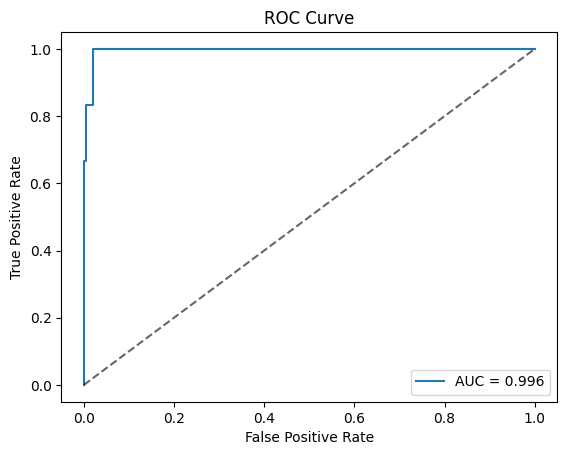

              precision    recall  f1-score   support

           0      0.996     0.987     0.991       234
           1      0.625     0.833     0.714         6

    accuracy                          0.983       240
   macro avg      0.810     0.910     0.853       240
weighted avg      0.986     0.983     0.984       240



In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score, classification_report
)

# 1) 取得分數 (probability 或 decision_function)
if hasattr(best_model, "predict_proba"):
    y_score = best_model.predict_proba(X_test)[:, 1]
else:
    y_score = best_model.decision_function(X_test)

y_pred = best_model.predict(X_test)

# 2) ROC 曲線 + AUC
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'k--', alpha=0.6)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve'); plt.legend(); plt.show()

# 3) (選用) 分類報告
print(classification_report(y_test, y_pred, digits=3))

Baseline accuracy with all features: 0.9833

Top 10 drop-feature results:
                dropped_feature  accuracy
                            age  0.979167
       screen_time_before_sleep  0.979167
              physical_activity  0.979167
                addiction_level  0.979167
                    gender_male  0.979167
          platform_usage_TikTok  0.979167
   social_interaction_level_low  0.979167
       platform_usage_Instagram  0.975000
           academic_performance  0.970833
social_interaction_level_medium  0.962500

Worst 10 drop-feature results:
                dropped_feature  accuracy
                    gender_male  0.979167
          platform_usage_TikTok  0.979167
   social_interaction_level_low  0.979167
       platform_usage_Instagram  0.975000
           academic_performance  0.970833
social_interaction_level_medium  0.962500
                   stress_level  0.950000
                  anxiety_level  0.941667
       daily_social_media_hours  0.929167
            

<Figure size 1200x382 with 0 Axes>

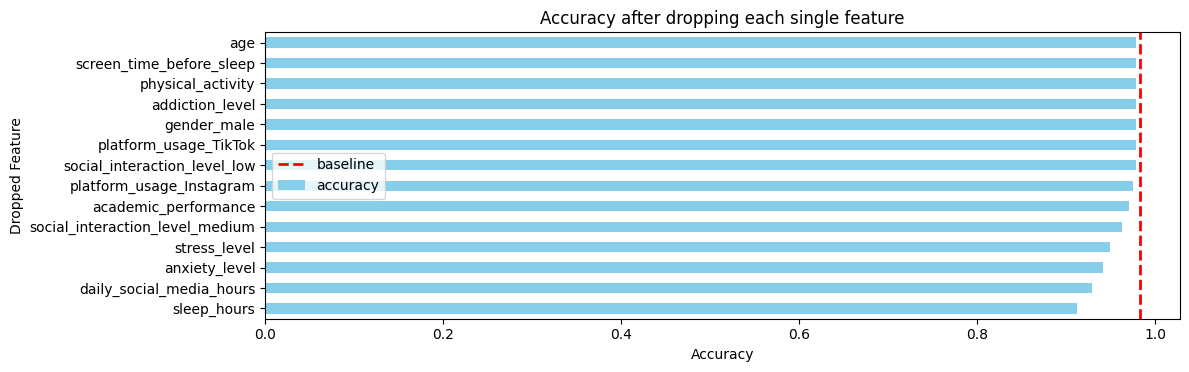

<Figure size 1200x382 with 0 Axes>

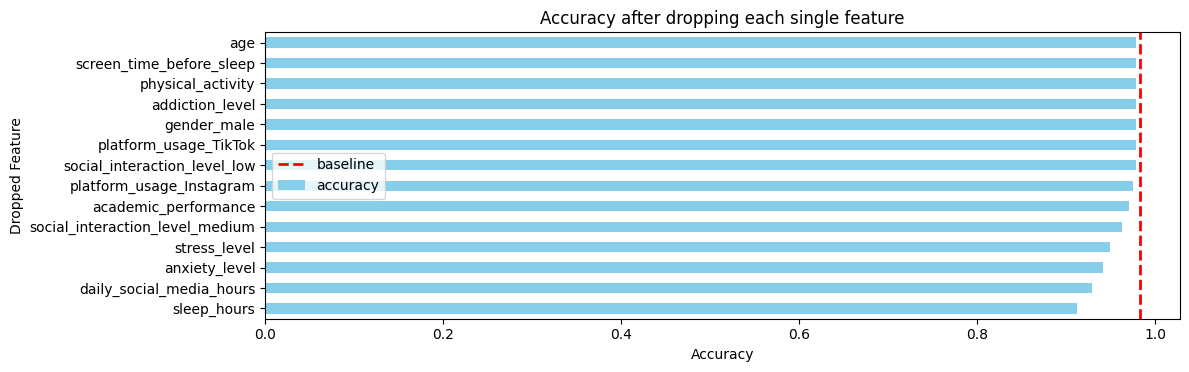

<Figure size 1200x800 with 0 Axes>

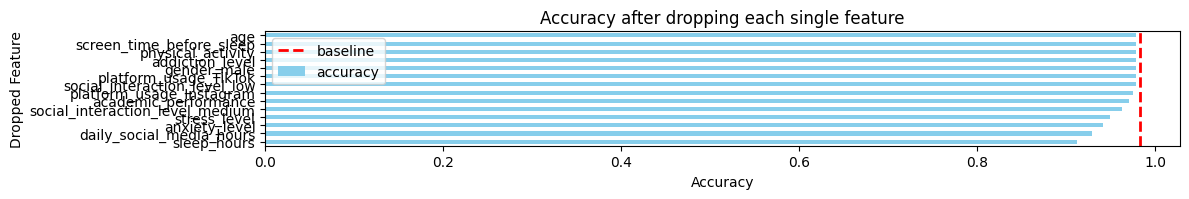

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score

feature_names = X.columns.tolist()
results = []

# 先算 full-feature baseline accuracy
baseline_acc = accuracy_score(y_test, best_model.predict(X_test))
print(f"Baseline accuracy with all features: {baseline_acc:.4f}\n")

for drop_feature in feature_names:
    keep_features = [c for c in feature_names if c != drop_feature]
    X_reduced = X[keep_features]

    X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
        X_reduced, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler_red = StandardScaler()
    X_train_red = scaler_red.fit_transform(X_train_red)
    X_test_red = scaler_red.transform(X_test_red)

    model_red = SGDClassifier(
        random_state=42,
        class_weight='balanced',
        **grid.best_params_
    )
    model_red.fit(X_train_red, y_train_red)

    y_pred_red = model_red.predict(X_test_red)
    acc_red = accuracy_score(y_test_red, y_pred_red)
    results.append((drop_feature, acc_red))

result_df = pd.DataFrame(results, columns=['dropped_feature', 'accuracy'])
result_df = result_df.sort_values(by='accuracy', ascending=False).reset_index(drop=True)

print('Top 10 drop-feature results:')
print(result_df.head(10).to_string(index=False))
print('\nWorst 10 drop-feature results:')
print(result_df.tail(10).to_string(index=False))
print(f"\nCount of drop-feature models with accuracy >= baseline: {sum(result_df['accuracy'] >= baseline_acc)} / {len(result_df)}")

# 繪製 bar chart
plt.figure(figsize=(12, len(result_df) * 0.13 + 2))
ax = result_df.plot.barh(
    x='dropped_feature',
    y='accuracy',
    legend=False,
    color='skyblue',
    figsize=(12, len(result_df) * 0.13 + 2)
)
ax.axvline(baseline_acc, color='red', linestyle='--', linewidth=2, label='baseline')
ax.set_xlabel('Accuracy')
ax.set_ylabel('Dropped Feature')
ax.set_title('Accuracy after dropping each single feature')
ax.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 繪製 bar chart
plt.figure(figsize=(12, len(result_df) * 0.13 + 2))
ax = result_df.plot.barh(
    x='dropped_feature',
    y='accuracy',
    legend=False,
    color='skyblue',
    figsize=(12, len(result_df) * 0.13 + 2)
)
ax.axvline(baseline_acc, color='red', linestyle='--', linewidth=2, label='baseline')
ax.set_xlabel('Accuracy')
ax.set_ylabel('Dropped Feature')
ax.set_title('Accuracy after dropping each single feature')
ax.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 繪製 bar chart
plt.figure(figsize=(12, 8))
ax = result_df.plot.barh(
    x='dropped_feature',
    y='accuracy',
    legend=False,
    color='skyblue',
    figsize=(12, len(result_df) * 0.15)
)
ax.axvline(baseline_acc, color='red', linestyle='--', linewidth=2, label='baseline')
ax.set_xlabel('Accuracy')
ax.set_ylabel('Dropped Feature')
ax.set_title('Accuracy after dropping each single feature')
ax.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()